In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


<center style="font-family:verdana;"><h1 style="font-size:200%; padding: 10px; background: #001f3f;"><b style="color:orange;">Le Petit Prince Space Travels</b></h1></center>

"The Little Prince chose to leave his tiny home planet ( Asteroid 325 but that people on Earth call Asteroid B-612). He traveled to a series of asteroids, each featuring a narrow-minded grown-up who has been reduced to a function."

"The planets that the Little Prince visited, including asteroids 326, 327, 328, 329, and 330. The last planet that he visited was the Earth.

"The little prince passed by neighboring asteroids and encounters. On the first six planets the little prince visited, he met a king, a vain man, a drunkard, a businessman, a lamplighter, and a geographer."

"The first was a king who required obedience but had no subjects until the arrival of the prince. The sole inhabitant of the next planet was a conceited man who wanted nothing from the prince but flattery. (=follower?)"

"All of whom lived alone and were overly consumed by their chosen occupations. Such strange behavior both amused and perturbed the little prince. He did not understand their need to order people around, to be admired (votes?), and to own everything (rankings?). With the exception of the lamplighter, whose dogged faithfulness he admired, the little prince did not think much of the adults he visited, and he did not learn anything useful." 

Maybe, The Petit Prince could come again and learn a bit more on Kaggle.

https://www.sparknotes.com/lit/littleprince/summary/

The Little Prince written and illustrated by Antoine de Saint Exupéry.

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT2FUgz92EpFmr2bVDuP1LfV7Yyk1d9XXFmsg&usqp=CAU)facebook.com

In [2]:
train = pd.read_csv('../input/spaceship-titanic/train.csv',index_col=0)
test_data  = pd.read_csv('../input/spaceship-titanic/test.csv', index_col=0)
sample     = pd.read_csv('../input/spaceship-titanic/sample_submission.csv')

In [3]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

!pip install ptitprince

  Preparing metadata (setup.py) ... done
     |████████████████████████████████| 51 kB 248 kB/s            
  Created wheel for ptitprince: filename=ptitprince-0.2.5-py3-none-any.whl size=8426 sha256=84dfd6ce98a577c21f87e69b1d5d3f6991737e026c6dd277b3fff17816883562
  Stored in directory: /root/.cache/pip/wheels/58/a5/f2/55920bbc5d0e6fb74b2370e1e52e07c236ba7b621236ea5a81
Successfully built ptitprince


In [4]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

from ptitprince import RainCloud
from ptitprince import PtitPrince as pt

In [5]:
train.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
PassengerId,,,,,,,,,,,,,
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [6]:
#Convert Boolean into integer. Thanks to Carl McBride Ellis

train.CryoSleep = train.CryoSleep.replace({True: 1, False: 0})
train.VIP = train.VIP.replace({True: 1, False: 0})
train.Transported = train.Transported.replace({True: 1, False: 0})

In [7]:
train.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
PassengerId,,,,,,,,,,,,,
0001_01,Europa,0.0,B/0/P,TRAPPIST-1e,39.0,0.0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0
0002_01,Earth,0.0,F/0/S,TRAPPIST-1e,24.0,0.0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1
0003_01,Europa,0.0,A/0/S,TRAPPIST-1e,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0
0003_02,Europa,0.0,A/0/S,TRAPPIST-1e,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0
0004_01,Earth,0.0,F/1/S,TRAPPIST-1e,16.0,0.0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1


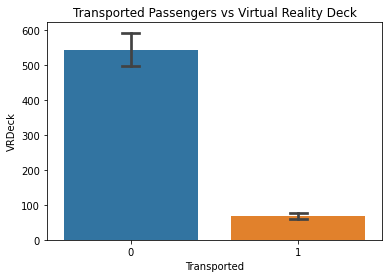

In [10]:
#Till now I don't know the meanig of that Virtual Reality Deck

import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x="Transported", y="VRDeck", data=train, capsize= .1)
plt.title('Transported Passengers vs Virtual Reality Deck');

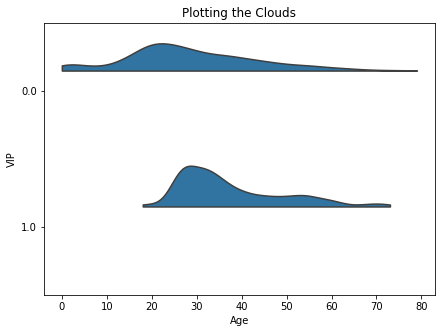

In [34]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

# plotting the clouds
f, ax = plt.subplots(figsize=(7, 5))
dy="VIP"
dx="Age"
ort="h"
pal = sns.color_palette(n_colors=1)

ax=pt.half_violinplot(x=dx, y=dy, data=train, palette=pal, bw=.2, cut=0.,
                      scale="area", width=.6, inner=None, orient=ort)
plt.title('Plotting the Clouds');

#Compare the half_violinplot above with the Little Prince's drawing below. 

![](https://i.pinimg.com/originals/27/17/71/2717719c2acfbed8868838c91f826e3b.jpg)pinterest.com

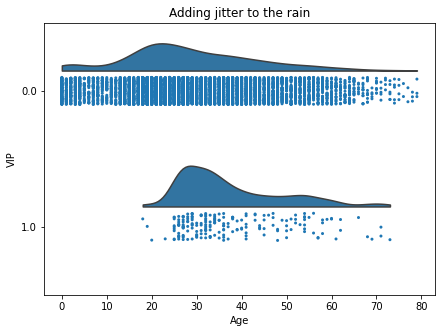

In [35]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

# adding jitter to the rain
f, ax = plt.subplots(figsize=(7, 5))
ax=pt.half_violinplot(x=dx, y=dy, data=train, palette=pal, bw=.2, cut=0.,
                      scale="area", width=.6, inner=None, orient=ort)
ax=sns.stripplot(x=dx, y=dy, data=train, palette=pal, edgecolor="white",
                 size=3, jitter=1, zorder=0, orient=ort)

plt.title('Adding jitter to the rain');

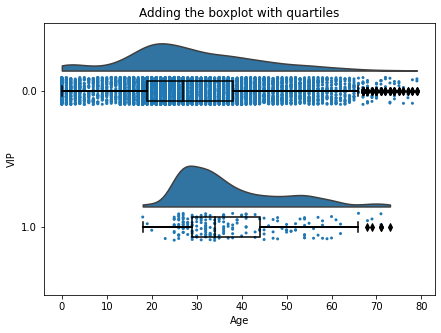

In [36]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

#adding the boxplot with quartiles
f, ax = plt.subplots(figsize=(7, 5))
ax=pt.half_violinplot(x=dx, y=dy, data=train, palette=pal, bw=.2, cut=0.,
                      scale="area", width=.6, inner=None, orient=ort)
ax=sns.stripplot(x=dx, y=dy, data=train, palette=pal, edgecolor="white",
                 size=3, jitter=1, zorder=0, orient=ort)
ax=sns.boxplot(x=dx, y=dy, data=train, color="black", width=.15, zorder=10,
               showcaps=True, boxprops={'facecolor': 'none', "zorder": 10},
               showfliers=True, whiskerprops={'linewidth': 2, "zorder": 10},
               saturation=1, orient=ort)

plt.title('Adding the boxplot with quartiles');

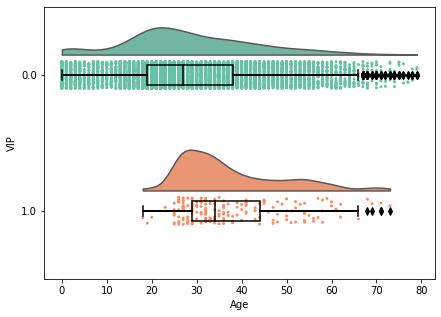

In [19]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

pal = "Set2"
f, ax = plt.subplots(figsize=(7, 5))
ax=pt.half_violinplot(x=dx, y=dy, data=train, palette=pal, bw=.2, cut=0.,
                      scale="area", width=.6, inner=None, orient=ort)
ax=sns.stripplot(x=dx, y=dy, data=train, palette=pal, edgecolor="white",
                 size=3, jitter=1, zorder=0, orient=ort)
ax=sns.boxplot(x=dx, y=dy, data=train, color="black", width=.15, zorder=10,
               showcaps=True, boxprops={'facecolor': 'none', "zorder": 10},
               showfliers=True, whiskerprops={'linewidth': 2, "zorder": 10},
               saturation=1, orient=ort)

plt.title('Half_Violinplot/Boxplot/Stripplot');

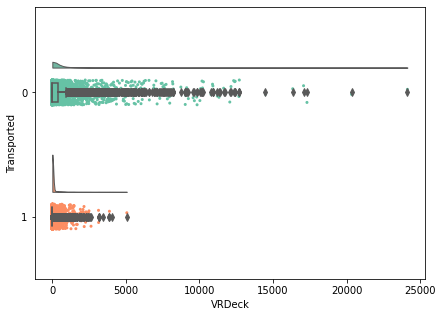

In [20]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

#same thing with a single command: now x **must** be the categorical value
sigma = .2
dy = "VRDeck"
dx = "Transported"
ort = "h"
f, ax = plt.subplots(figsize=(7, 5))

pt.RainCloud(x=dx, y=dy, data=train, palette=pal, bw=sigma,
             width_viol=.6, ax=ax, orient=ort)



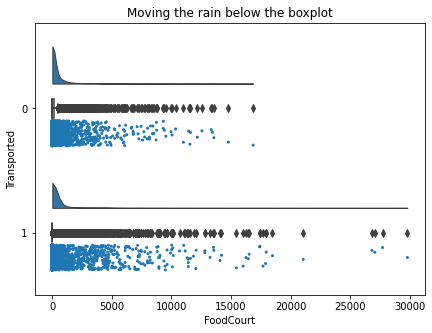

In [37]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

#moving the rain below the boxplot
sigma = .2
dy = "FoodCourt"
dx = "Transported"
ort = "h"
f, ax = plt.subplots(figsize=(7, 5))

pt.RainCloud(x=dx, y=dy, data=train, palette=pal, bw=sigma,
             width_viol=.6, ax=ax, orient=ort, move=.2)

plt.title('Moving the rain below the boxplot');

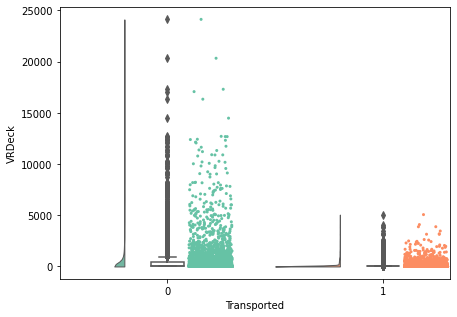

In [24]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

# Changing orientation
#moving the rain below the boxplot
sigma = .2
dy = "VRDeck"
dx = "Transported"
ort = "v"
f, ax = plt.subplots(figsize=(7, 5))

pt.RainCloud(x=dx, y=dy, data=train, palette=pal, bw=sigma,
             width_viol=.6, ax=ax, orient=ort, move=.2);

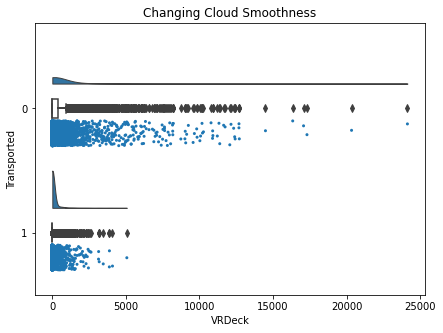

In [38]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

#changing cloud smoothness
#moving the rain below the boxplot
sigma = .5
dy = "VRDeck"
dx = "Transported"
ort = "h"
f, ax = plt.subplots(figsize=(7, 5))

pt.RainCloud(x=dx, y=dy, data=train, palette=pal, bw=sigma,
             width_viol=.6, ax=ax, orient=ort, move=.2)

plt.title('Changing Cloud Smoothness');

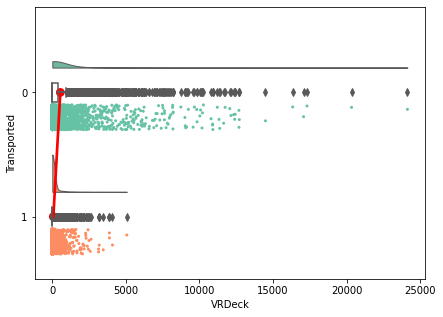

In [26]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

#adding a red line connecting the groups' mean value (useful for longitudinal data)
sigma = .5
dy = "VRDeck"
dx = "Transported"
ort = "h"
f, ax = plt.subplots(figsize=(7, 5))

pt.RainCloud(x=dx, y=dy, data=train, palette=pal, bw=sigma,
             width_viol=.6, ax=ax, orient=ort, move=.2, pointplot=True);

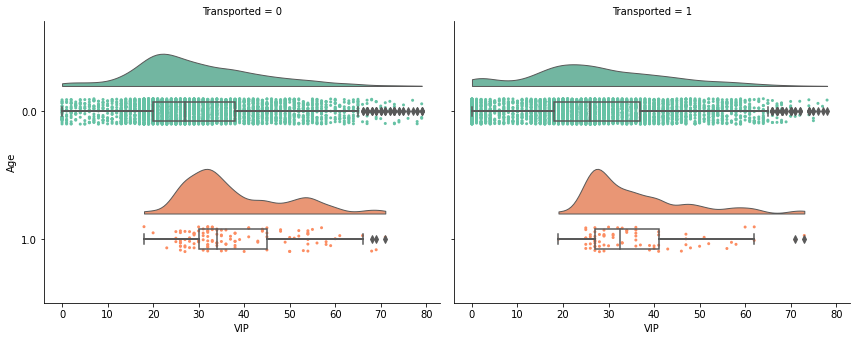

In [27]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

# Rainclouds with FacetGrid
g = sns.FacetGrid(train, col="Transported", height=6)
g = g.map_dataframe(pt.RainCloud, x="VIP", y="Age", data=train,
                    orient="h")

g.fig.subplots_adjust(top=0.75)

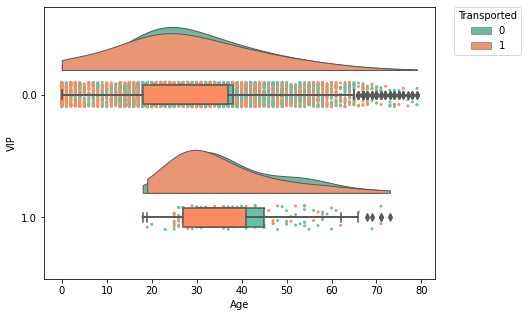

In [28]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

dy = "Age"
dx = "VIP"
ort = "h"
dhue = "Transported"
f, ax = plt.subplots(figsize=(7, 5))
ax=pt.RainCloud(x=dx, y=dy, hue=dhue, data=train, palette=pal, bw=sigma,
                 width_viol=.7, ax=ax, orient=ort)

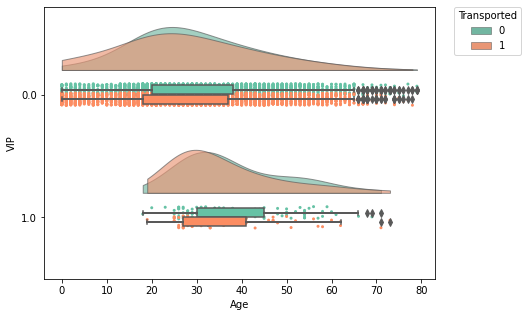

In [29]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

#The Doge Flag
dy = "Age"
dx = "VIP"
ort = "h"
dhue = "Transported"
f, ax = plt.subplots(figsize=(7, 5))
ax=pt.RainCloud(x=dx, y=dy, hue=dhue, data=train, palette=pal, bw=sigma,
                 width_viol=.7, ax=ax, orient=ort, alpha=0.65, dodge=True)

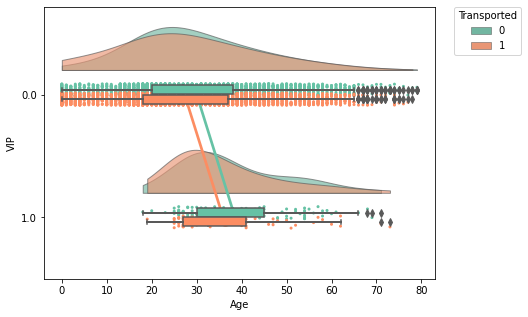

In [30]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

#same, with dodging and line
dy = "Age"
dx = "VIP"
ort = "h"
dhue = "Transported"
f, ax = plt.subplots(figsize=(7, 5))
ax=pt.RainCloud(x=dx, y=dy, hue=dhue, data=train, palette=pal, bw=sigma,
                 width_viol=.7, ax=ax, orient=ort, alpha=0.65, dodge=True, pointplot=True)

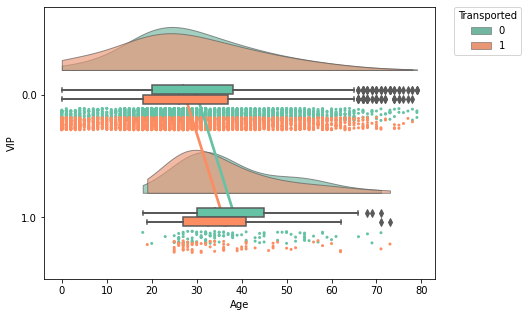

In [31]:
#PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

#moving the rain under the boxplot

dy = "Age"
dx = "VIP"
ort = "h"
dhue = "Transported"
f, ax = plt.subplots(figsize=(7, 5))
ax=pt.RainCloud(x=dx, y=dy, hue=dhue, data=train, palette=pal, bw=sigma,
                 width_viol=.7, ax=ax, orient=ort, alpha=0.65, dodge=True, pointplot=True, move=0.2)

#Acknowledgement:

PtitPrince by CurryPurin https://www.kaggle.com/currypurin/titanic-raincloud-tutorial/notebook

https://github.com/pog87/PtitPrince

https://github.com/pog87/PtitPrince/blob/master/tutorial_python/raincloud_tutorial_python.ipynb

![](https://pics.onsizzle.com/the-little-prince-stardust-crusader-69682150.png)onsizzle.com

#Very likely, a Python snake.

In [33]:
#Code by Olga Belitskaya https://www.kaggle.com/olgabelitskaya/sequential-data/comments
from IPython.display import display,HTML
c1,c2,f1,f2,fs1,fs2=\
'#eb3434','#eb3446','Akronim','Smokum',30,15
def dhtml(string,fontcolor=c1,font=f1,fontsize=fs1):
    display(HTML("""<style>
    @import 'https://fonts.googleapis.com/css?family="""\
    +font+"""&effect=3d-float';</style>
    <h1 class='font-effect-3d-float' style='font-family:"""+\
    font+"""; color:"""+fontcolor+"""; font-size:"""+\
    str(fontsize)+"""px;'>%s</h1>"""%string))
    
    
dhtml('Thank you CurryPurin for the Petit Prince script')